# Snowline Data

In [1]:
import os
import geopandas as gpd
import pandas as pd
import regionmask
import rasterio
import rioxarray
import xarray as xr
import requests
import elevation

import matplotlib.pyplot as plt
%matplotlib inline

/opt/anaconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Download UW 800m Data

# base_url = "https://climate.arizona.edu/data/UA_SWE/DailyData_800m/"
# output_dir = "../Dataset/Snowline_Data"
# os.makedirs(output_dir, exist_ok=True)

# # Define your 5-year range (e.g., Water Years 2019-2023)
# start_date = "2025-11-01"
# end_date = "2025-12-18"
# dates = pd.date_range(start=start_date, end=end_date, freq='D')

# # 2. Download Loop
# for date in dates:
#     # Determine the Water Year folder
#     # If month >= 10, it belongs to the next year's WY folder
#     wy = date.year if date.month < 10 else date.year + 1
#     wy_folder = f"WY{wy}"
    
#     # File naming convention: 4-digit year, 2-digit month, 2-digit day
#     file_name = f"UA_SWE_Depth_800m_v1_{date.strftime('%Y%m%d')}_provisional.nc"
#     url = f"{base_url}{wy_folder}/{file_name}"
#     save_path = os.path.join(output_dir, file_name)

#     if not os.path.exists(save_path):
#         print(f"Downloading: {file_name}...")
#         try:
#             r = requests.get(url, timeout=10)
#             if r.status_code == 200:
#                 with open(save_path, 'wb') as f:
#                     f.write(r.content)
#             else:
#                 print(f"  Failed (Status {r.status_code}): {url}")
#         except Exception as e:
#             print(f"  Error downloading {file_name}: {e}")


In [4]:
# create UA SWE dataset (800 m)

path_ua = "../Dataset/Snowline_Data/"
files_ua = path_ua + "UA_SWE_Depth_800m_v1_*_*.nc"

ds = xr.open_mfdataset(files_ua, engine="netcdf4", data_vars="all")

In [5]:
ds

<xarray.Dataset> Size: 64GB
Dimensions:   (time: 364, time_str_len: 11, lat: 3105, lon: 7025)
Coordinates:
  * time      (time) datetime64[ns] 3kB 2024-10-01 2024-10-02 ... 2025-09-30
  * lat       (lat) float32 12kB 24.07 24.08 24.08 24.09 ... 49.92 49.92 49.93
  * lon       (lon) float32 28kB -125.0 -125.0 -125.0 ... -66.5 -66.49 -66.48
Dimensions without coordinates: time_str_len
Data variables:
    crs       (time) |S1 364B b'' b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    time_str  (time_str_len, time) |S1 4kB dask.array<chunksize=(11, 1), meta=np.ndarray>
    SWE       (time, lat, lon) float32 32GB dask.array<chunksize=(1, 1553, 3513), meta=np.ndarray>
    DEPTH     (time, lat, lon) float32 32GB dask.array<chunksize=(1, 1553, 3513), meta=np.ndarray>

In [6]:
# read shapefile
skagit_boundary = gpd.read_file('../Dataset/ShapeFiles/SkagitBoundary.json')

dir =  os.path.split(os.getcwd())[0]
file_path = dir + '/Dataset/ShapeFiles/SkagitRiver_90mDEM.tif'
elevation.clip(bounds=(-122.6,47.5,-120,49.5), output = file_path)

make: Nothing to be done for `download'.
make: Nothing to be done for `all'.
cp SRTM1.vrt SRTM1.20b19716b6c34c819ac12d12082106c6.vrt
gdal_translate -q -co TILED=YES -co COMPRESS=DEFLATE -co ZLEVEL=9 -co PREDICTOR=2 -projwin -122.6 49.5 -120.0 47.5 SRTM1.20b19716b6c34c819ac12d12082106c6.vrt /Users/jenniferkim/Downloads/SnowComp-main/Dataset/ShapeFiles/SkagitRiver_90mDEM.tif
rm -f SRTM1.20b19716b6c34c819ac12d12082106c6.vrt


In [7]:
# read in the DEM 
dem = rioxarray.open_rasterio(
    file_path,
    masked=True,
)

In [8]:
# clip DEM
poly = skagit_boundary.geometry
skagit_dem = dem.rio.clip(poly)

# clip dataset
poly = skagit_boundary.geometry.to_list()
ds = ds.SWE.rio.set_spatial_dims(x_dim='lon', y_dim='lat', inplace=True)
ds = ds.rio.write_crs("epsg:4326", inplace=True)
ds = ds.rio.clip(poly, crs="epsg:4326")

In [9]:
skagit_swe = ds.rio.write_crs("EPSG:4326")
skagit_dem = skagit_dem.rio.write_crs("EPSG:4326")

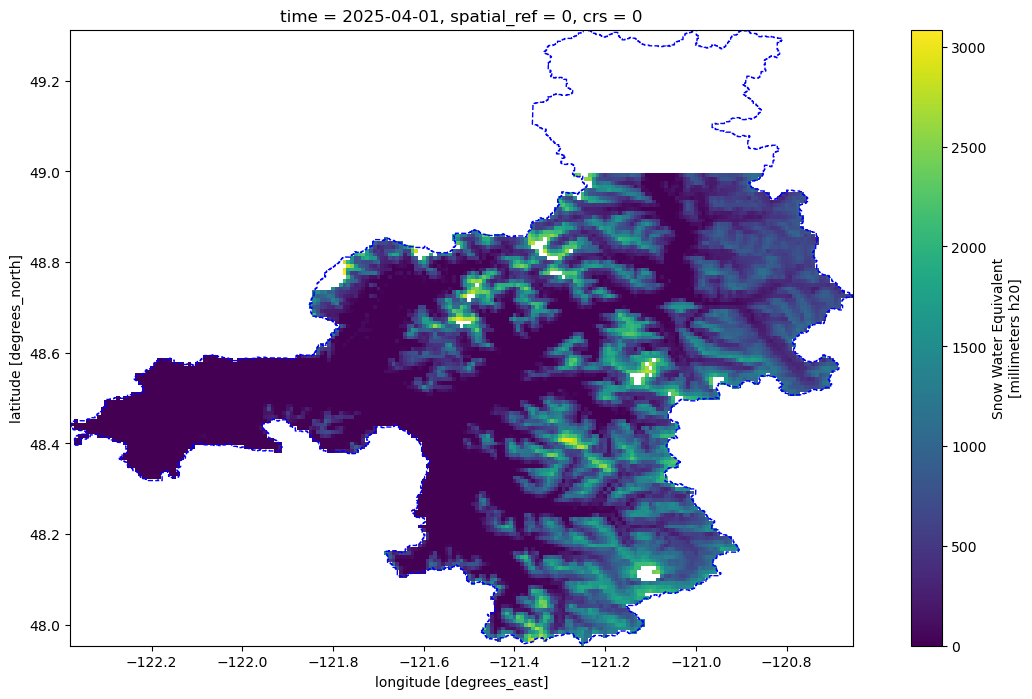

In [10]:
fig, ax = plt.subplots(figsize=(15,8))

date = pd.to_datetime('2025-04-01', format='%Y-%m-%d')
one_day = skagit_swe.sel(time=date, method='nearest')
one_day.plot(ax=ax)

skagit_boundary.plot(ax=ax, edgecolor='blue', linestyle='--', facecolor='none');
ax.set_aspect(1)

In [11]:
# match shape of dem to swe
bbox_swe = skagit_swe.rio.bounds()
bbox_dem = skagit_dem.rio.bounds()

swe_left, swe_bottom, swe_right, swe_top = bbox_swe
dem_left, dem_bottom, dem_right, dem_top = bbox_dem

minx = max(swe_left, dem_left)
maxx = min(swe_right, dem_right)
miny = max(swe_bottom, dem_bottom)
maxy = min(swe_top, dem_top)

skagit_swe = skagit_swe.rio.clip_box(minx, miny, maxx, maxy)
dem_clip = dem.rio.clip_box(minx, miny, maxx, maxy)
skagit_dem = dem_clip.rio.reproject_match(skagit_swe.isel(time=0))

In [12]:
print(skagit_swe.shape)
print(skagit_dem.shape)

(364, 163, 207)
(1, 163, 207)


In [13]:
import numpy as np
bins = np.arange(0, 3000, 30)

In [64]:
def find_snowline(swe_t, dem, bins, snow_thresh=5, elev_thresh=0.3):
    swe = swe_t > snow_thresh
    snow_frac = []
    
    for y1, y2 in zip(bins[:-1], bins[1:]):
        elev_mask = (dem >= y1) & (dem < y2)
        total_pixels = elev_mask.sum()

        if total_pixels == 0:
            snow_frac.append(np.nan)
            continue

        snow_pixels = (swe & elev_mask).sum()
        frac = snow_pixels / total_pixels
        snow_frac.append(frac)
        
    snow_frac = np.array(snow_frac)

    idx = np.where(snow_frac >= elev_thresh)[0]
    
    if len(idx) == 0:
        return np.nan

    return bins[idx[0]]

In [24]:
snowline_values = []

for t in range(skagit_swe.time.size):
    swe_t = skagit_swe.isel(time=t)
    swe_t_np = swe_t.values

    sl = find_snowline(
        swe_t_np,
        skagit_dem.values,
        bins,
        snow_thresh=5,
        elev_thresh=0.3,
    )

    snowline_values.append(sl)

In [16]:
snowline_da = xr.DataArray(
    snowline_values,
    coords={"time": skagit_swe.time},
    dims=["time"],
    name="snowline",
)

Text(0.5, 0, 'Time')

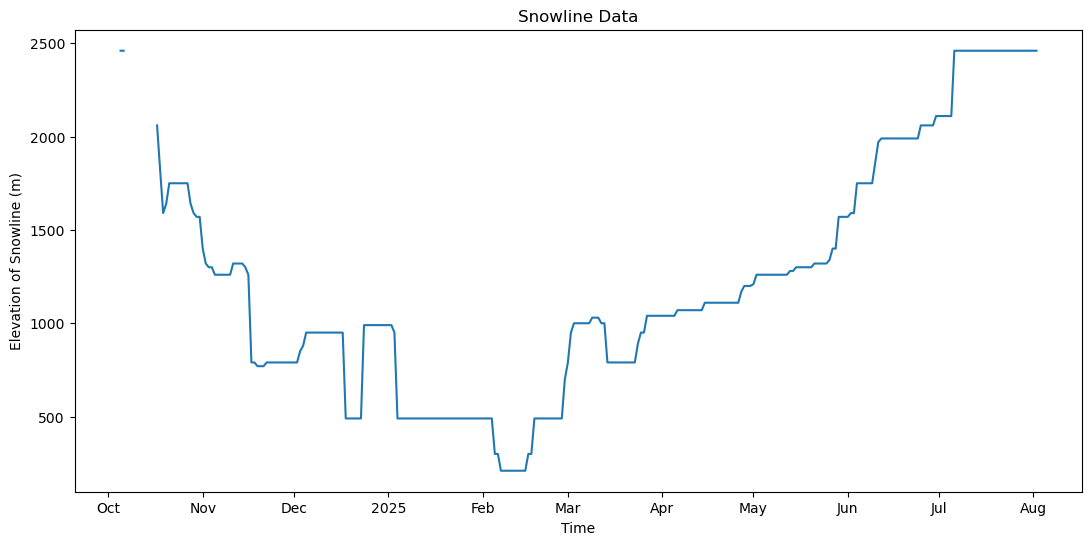

In [26]:
snowline_da.plot(figsize=(13, 6))
plt.title('Snowline Data')
plt.ylabel('Elevation of Snowline (m)')
plt.xlabel('Time')

## Analyze AR Event Data

In [18]:
import csv

ar_data = {}

with open('../Dataset/AR_Data/48N_event_data.csv') as f:
    reader = csv.reader(f)
    lines = list(reader)
    
    for line in lines:
        date = pd.to_datetime(line[2], format='%Y%m%d%H')
        date = pd.to_datetime(date.strftime("%Y-%m-%d"))
        scale = int(line[5])

        if date not in ar_data:
            ar_data[date] = {}
            
        ar_data[date] = scale


In [62]:
def filter_dates(
        scale: int,
        lower: pd.Timestamp,
        upper: pd.Timestamp) -> list[pd.Timestamp]:
    
    filtered = []
    dates = [date for date in ar_data.keys() if lower <= date <= upper]

    for d in dates:
        if ar_data[d] == scale:
            filtered.append(d)

    return filtered

In [20]:
upper = pd.to_datetime('2024-10-01')
lower = pd.to_datetime('2025-09-30')

dates_3 = filter_dates(3, upper, lower)
sl_events_3 = snowline_da.sel(time=dates_3, method='nearest')

dates_4 = filter_dates(4, upper, lower)
sl_events_4 = snowline_da.sel(time=dates_4, method='nearest')

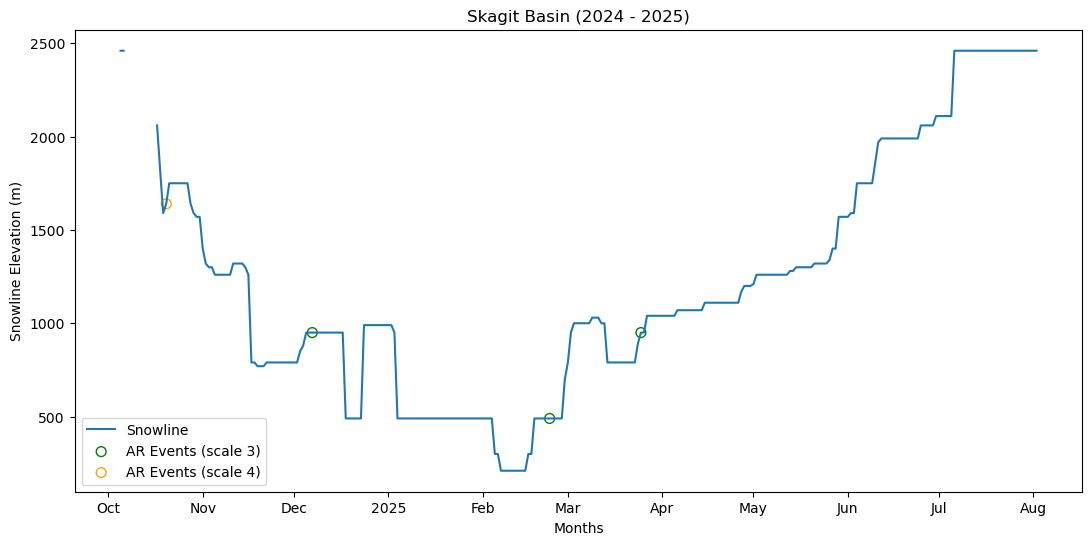

In [21]:
plt.figure(figsize=(13, 6))
snowline_da.plot(label='Snowline')

plt.scatter(dates_3, sl_events_3, facecolors='none', edgecolors='green', s=50, label="AR Events (scale 3)")
plt.scatter(dates_4, sl_events_4, facecolors='none', edgecolors='orange', s=50, label="AR Events (scale 4)")

plt.legend()
plt.xlabel("Months")
plt.ylabel("Snowline Elevation (m)")
plt.title("Skagit Basin (2024 - 2025)")
plt.show()